# Project: Matrix Multiplication Performance Benchmark for AI API Cost Simulation

## Objective
This project demonstrates the application of matrix multiplication and numerical computing techniques to model AI API resource consumption in a higher education environment.

A synthetic dataset representing 2,000 students is generated using reproducible probabilistic simulations. The notebook compares multiple matrix multiplication algorithms, evaluates their computational performance, and applies matrix-based operations to estimate AI API usage and associated costs.

The experiment integrates mathematical foundations, algorithm implementation, performance benchmarking, and scientific visualization to illustrate how numerical methods can support large-scale computational analysis.

## Business Problem
Universities are increasingly adopting Large Language Models (LLMs) for teaching, research, and administrative workflows. As AI adoption grows across thousands of students and multiple academic departments, monitoring token consumption and controlling API costs become increasingly important.

Institutional IT teams require efficient computational methods to:

- Estimate AI API costs across large student populations.
- Analyze token consumption patterns.
- Compare pricing across multiple AI models.
- Simulate future infrastructure demand.
- Support data-driven budgeting and resource allocation decisions.

## Data Science Approach
This notebook applies numerical computing and matrix-based methods to simulate AI service utilization and evaluate computational performance.

The workflow includes:

- Synthetic data generation using reproducible random sampling.
- Modeling heavy-tailed token usage with a log-normal distribution.
- Converting tabular data into NumPy matrices.
- Implementing matrix multiplication from first principles using nested loops.
- Developing a cache-aware blocked (tiled) matrix multiplication algorithm.
- Comparing custom implementations with NumPy's optimized matmul.
- Benchmarking execution time across multiple matrix dimensions.
- Computing descriptive statistics and visualizing performance trends.

## Tech Stack & Core Concepts
Tech Stack:
- Programming Language: Python
- Libraries: NumPy, Pandas, Matplotlib, Time

Numerical Computing Concepts:
- Matrix Multiplication & Linear Algebra
- Vectorization & Broadcasting
- Random Sampling & Computational Complexity ($O(N^3)$)
- Cache-Aware Optimization & Performance
- Benchmarking Scientific Visualization

## Business Impact
This project illustrates how numerical computing can support AI infrastructure planning in higher education. Potential applications include estimating institution-wide AI API expenditures, evaluating pricing scenarios across multiple LLM providers, identifying unusually high token consumption for operational monitoring, and supporting budget forecasting through simulation.

In [29]:
# Import libraries
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)

### Environment Setup & Synthetic Data Generation

Many real-world computing workloads exhibit heavy-tailed behavior, where most users consume relatively few computational resources while a small proportion of power users account for a disproportionately large share of overall usage. Examples include cloud computing, web traffic, and AI API token consumption.

To simulate this behavior, the synthetic dataset is generated using log-normal distributions, which naturally produce positive-valued observations with a long right tail.
The distribution parameters were chosen to create a realistic simulation rather than to replicate any specific production dataset:

- Input tokens: LogNormal(mean=12.5, sigma=0.8)
- Output tokens: LogNormal(mean=11.8, sigma=0.8)

These values generate a workload where most simulated students have moderate token usage, while a relatively small number exhibit substantially higher consumption. This reflects the qualitative behavior commonly observed in many cloud-based computing services and provides a suitable dataset for demonstrating matrix-based cost modeling and performance benchmarking.

**Note**: The distribution parameters and pricing values are illustrative and were selected for simulation purposes. They are not intended to represent actual usage statistics or commercial pricing from any AI service provider.

Why mean=12.5 and mean=11.8?

In NumPy's rng.lognormal(mean, sigma), the mean and sigma parameters describe the underlying normal distribution of the logarithm of the data, not the mean and standard deviation of the generated values themselves.
Specifically:
- mean=12.5 sets a higher central tendency for simulated input token counts.
- mean=11.8 generates somewhat smaller output token counts.
- sigma=0.8 controls the variability, producing a pronounced right-skewed distribution with occasional high-usage outliers.

The chosen values produce token counts on the order of hundreds of thousands, which are large enough to create meaningful differences in simulated API costs while preserving the heavy-tailed characteristics needed for the numerical computing demonstration.

In [30]:
# Reproducible administrative seed instantiation
rng = np.random.default_rng(seed=42)
num_students = 2000

# Generate heavy-tailed student consumption patterns (Log-Normal Distribution)
input_tokens_raw = rng.lognormal(mean=12.5, sigma=0.8, size=num_students)
output_tokens_raw = rng.lognormal(mean=11.8, sigma=0.8, size=num_students)
api_calls_raw = (input_tokens_raw * 0.002 + rng.integers(10, 50, size=num_students)).astype(int)

# Structural educational tier grouping
roles = rng.choice(['Undergraduate', 'Graduate Researcher', 'Faculty/Staff'], 
                   size=num_students, p=[0.70, 0.22, 0.08])

student_df = pd.DataFrame({
    'Student_ID': [f"STU-{1000+i}" for i in range(num_students)],
    'Academic_Role': roles,
    'Input_Tokens': np.round(input_tokens_raw).astype(int),
    'Output_Tokens': np.round(output_tokens_raw).astype(int),
    'API_Calls': api_calls_raw
})

print(f"Dataframe Shape: {student_df.shape}")
student_df.head(5)

Dataframe Shape: (2000, 5)


,Student_ID,Academic_Role,Input_Tokens,Output_Tokens,API_Calls
0,STU-1000,Faculty/Staff,342413,92822,700
1,STU-1001,Undergraduate,116776,78221,251
2,STU-1002,Undergraduate,489119,188567,996
3,STU-1003,Undergraduate,569465,162996,1160
4,STU-1004,Graduate Researcher,56341,43311,130


In [31]:
student_df.describe()

,Input_Tokens,Output_Tokens,API_Calls
count,2.000000e+03,2.000000e+03,2000.000000
mean,3.526137e+05,1.861939e+05,734.321000
std,3.249294e+05,1.766635e+05,649.998455
min,1.449100e+04,1.148700e+04,60.000000
25%,1.508442e+05,7.793525e+04,333.250000
50%,2.635575e+05,1.347140e+05,553.500000
75%,4.334535e+05,2.300938e+05,897.000000
max,3.412934e+06,1.576645e+06,6869.000000


In [32]:
# Calculate summary of usage patterns across academic roles.
role_summary = (
    student_df.groupby("Academic_Role")
    .agg(
        Students=("Student_ID", "count"),
        Mean_Input_Tokens=("Input_Tokens", "mean"),
        Mean_Output_Tokens=("Output_Tokens", "mean"),
        Mean_API_Calls=("API_Calls", "mean"),
        Total_API_Calls=("API_Calls", "sum"),
    )
    .round(2)
)

role_summary

,Students,Mean_Input_Tokens,Mean_Output_Tokens,Mean_API_Calls,Total_API_Calls
Academic_Role,,,,,
Faculty/Staff,136,349560.04,188280.24,727.84,98986
Graduate Researcher,449,365932.47,171500.08,760.83,341613
Undergraduate,1415,348681.02,190655.93,726.53,1028043


### Formulating the Cost Simulation Matrix Operations
To map raw utilization metrics to business costs, we convert our tabular data into a normalized matrix (expressed in millions of tokens) and multiply it by an AI provider pricing matrix.

**Note**: Pricing values are illustrative and were selected for simulation purposes. They are not intended to represent actual usage statistics or commercial pricing from any AI service provider.

In [33]:
# Normalize user arrays to matrix format (per Million tokens)
usage_matrix = student_df[['Input_Tokens', 'Output_Tokens']].to_numpy() / 1_000_000

# Pricing Matrix Setup (per Million tokens)
# Rows: Token Types [Input_Cost_Per_M, Output_Cost_Per_M]
# Columns: AI Models [ChatGPT GPT-4o, Gemini 1.5 Pro, Claude 3.5 Sonnet]
pricing_matrix = np.array([
    [2.50, 1.25, 3.00],   # Input Costs per Million Tokens
    [10.00, 5.00, 15.00]  # Output Costs per Million Tokens
])

model_names = ['ChatGPT GPT-4o', 'Gemini 1.5 Pro', 'Claude 3.5 Sonnet']

print(f"Usage Matrix Shape: {usage_matrix.shape}")
print(f"Pricing Matrix Shape: {pricing_matrix.shape}")

Usage Matrix Shape: (2000, 2)
Pricing Matrix Shape: (2, 3)


In [34]:
def compute_institutional_costs(usage_data: np.ndarray, pricing_rules: np.ndarray, model_list: list, df: pd.DataFrame) -> tuple:
    """
    Computes total AI API usage costs per student across multiple model providers 
    using matrix multiplication and integrates the results into the master DataFrame.
    """
    # Defensive dimension matching check
    if usage_data.shape[1] != pricing_rules.shape[0]:
        raise ValueError(
            f"Dimension mismatch for matrix multiplication: "
            f"Usage matrix inner dimension ({usage_data.shape[1]}) must match "
            f"Pricing matrix inner dimension ({pricing_rules.shape[0]})."
        )
        
    # Matrix Multiplication transformation: (N x 2) @ (2 x M) -> (N x M)
    cost_matrix = np.matmul(usage_data, pricing_rules)
    
    # Track the newly created columns dynamically
    cost_columns = []
    for idx, name in enumerate(model_list):
        col_name = f"Cost_{name.replace(' ', '_')}"
        df[col_name] = cost_matrix[:, idx]
        cost_columns.append(col_name)
        
    # Calculate global aggregate institutional totals
    aggregated_totals = df[cost_columns].sum()
    aggregated_totals.index = model_list
    
    return df, aggregated_totals

# Execute Cost Projection Model
student_df, total_costs = compute_institutional_costs(
    usage_data=usage_matrix, 
    pricing_rules=pricing_matrix, 
    model_list=model_names, 
    df=student_df
)

print("--- Simulated Institutional Expenditure Totals ---")
for model, cost in total_costs.items():
    print(f"{model}: ${cost:,.2f}")

--- Simulated Institutional Expenditure Totals ---
ChatGPT GPT-4o: $5,486.95
Gemini 1.5 Pro: $2,743.47
Claude 3.5 Sonnet: $7,701.50


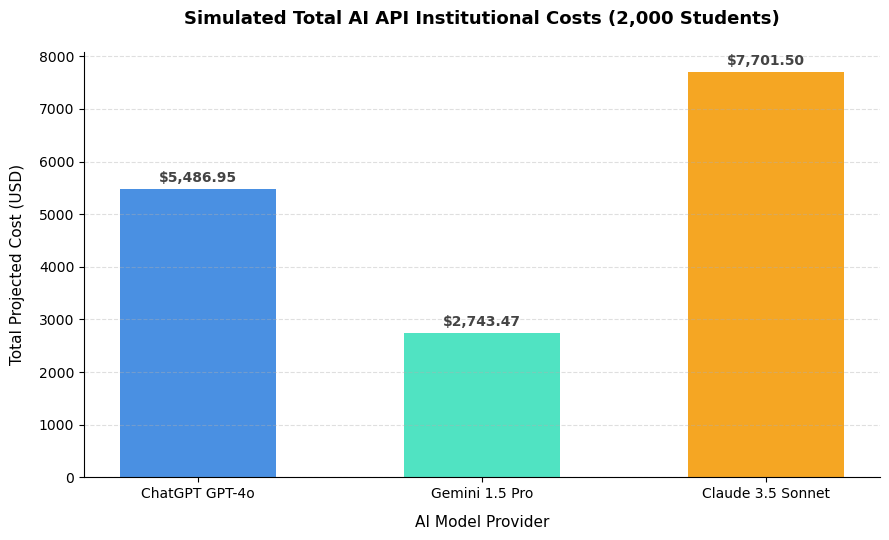

In [35]:
# Scientific visualization of cost simulation
plt.figure(figsize=(9, 5.5), dpi=100)
colors = ['#4A90E2', '#50E3C2', '#F5A623']
bars = plt.bar(total_costs.index, total_costs.values, color=colors, width=0.55)

plt.title('Simulated Total AI API Institutional Costs (2,000 Students)', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('AI Model Provider', fontsize=11, labelpad=10)
plt.ylabel('Total Projected Cost (USD)', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + (max(total_costs.values) * 0.01),
             f'${height:,.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#444444')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("output/institutional_costs.png", dpi=300, bbox_inches="tight")
plt.show()

### Core From-Scratch Mathematical Functions
Given $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, their matrix product is $C = AB$, where each element is defined as:$$c_{ij} = \sum_{k=1}^{n} a_{ik}b_{kj}$$The resulting matrix has dimensions $C \in \mathbb{R}^{m \times p}$.

In [36]:
def matrix_multiply_naive(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """
    Standard 3-loop matrix multiplication from first principles.
    Asymptotic Time Complexity: O(N^3)
    Space Complexity: O(N^2)
    """
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    if cols_A != rows_B:
        raise ValueError(f"Dimension mismatch: {cols_A} columns in A cannot multiply {rows_B} rows in B.")
        
    C = np.zeros((rows_A, cols_B))
    for i in range(rows_A):
        for j in range(cols_B):
            acc = 0.0
            for k in range(cols_A):
                acc += A[i, k] * B[k, j]
            C[i, j] = acc
    return C

In [25]:
def matrix_multiply_tiled(A: np.ndarray, B: np.ndarray, block_size: int = 16) -> np.ndarray:
    """
    Cache-optimized blocked matrix multiplication framework.
    Note: Python interpreter overhead on the 6 nested loops typically 
    negates hardware cache benefits; best performance seen when compiled via Cython/Numba.
    """
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    if cols_A != rows_B:
        raise ValueError(f"Dimension mismatch: {cols_A} columns in A cannot multiply {rows_B} rows in B.")
        
    C = np.zeros((rows_A, cols_B))
    
    # Block loops
    for si in range(0, rows_A, block_size):
        for sj in range(0, cols_B, block_size):
            for sk in range(0, cols_A, block_size):
                # Core element-wise calculation loops within blocks
                for i in range(si, min(si + block_size, rows_A)):
                    for j in range(sj, min(sj + block_size, cols_B)):
                        acc = 0.0
                        for k in range(sk, min(sk + block_size, cols_A)):
                            acc += A[i, k] * B[k, j]
                        C[i, j] += acc
    return C

### Algorithm Correctness Verification

Before comparing execution times, both custom matrix multiplication implementations are validated against NumPy's matmul. The np.allclose() function checks that corresponding matrix elements are numerically equivalent within a small floating-point tolerance. This verification ensures that all benchmarked algorithms produce the same mathematical result before performance comparisons are made.

In [37]:
# Verify correctness of custom implementations
A_test = rng.random((5, 5))
B_test = rng.random((5, 5))

naive_result = matrix_multiply_naive(A_test, B_test)
tiled_result = matrix_multiply_tiled(A_test, B_test)
numpy_result = np.matmul(A_test, B_test)

assert np.allclose(naive_result, numpy_result), \
    "Naive implementation does not match NumPy."

assert np.allclose(tiled_result, numpy_result), \
    "Tiled implementation does not match NumPy."

print("✓ Both custom implementations match NumPy's matrix multiplication.")

✓ Both custom implementations match NumPy's matrix multiplication.


### Experimental Benchmark Testing Suite

In [38]:
matrix_dimensions = [10, 30, 60, 100, 150, 220]
naive_times, tiled_times, numpy_times = [], [], []

for N in matrix_dimensions:
    A_test = rng.random((N, N))
    B_test = rng.random((N, N))
    
    # Naive Loop Execution Tracker
    t0 = time.perf_counter()
    _ = matrix_multiply_naive(A_test, B_test)
    naive_times.append(time.perf_counter() - t0)
    
    # Tiled Cache Execution Tracker
    t1 = time.perf_counter()
    _ = matrix_multiply_tiled(A_test, B_test, block_size=16)
    tiled_times.append(time.perf_counter() - t1)
    
    # NumPy Optimized Vector Execution Tracker
    t2 = time.perf_counter()
    _ = np.matmul(A_test, B_test)
    numpy_times.append(time.perf_counter() - t2)

# Generate Quantitative Benchmark Analysis Report
benchmark = pd.DataFrame({
    "Matrix Size": matrix_dimensions,
    "Naive (s)": naive_times,
    "Tiled (s)": tiled_times,
    "NumPy (s)": numpy_times
})

benchmark["Speedup (Naive/NumPy)"] = benchmark["Naive (s)"] / benchmark["NumPy (s)"]
benchmark["Speedup (Tiled/NumPy)"] = benchmark["Tiled (s)"] / benchmark["NumPy (s)"]
benchmark.round(4)

,Matrix Size,Naive (s),Tiled (s),NumPy (s),Speedup (Naive/NumPy),Speedup (Tiled/NumPy)
0,10,0.0007,0.0011,0.0001,7.8464,11.5618
1,30,0.0159,0.0213,0.0002,74.1024,99.0475
2,60,0.1579,0.1797,0.0004,383.6596,436.5858
3,100,0.7393,0.8243,0.0005,1412.9930,1575.4841
4,150,2.4113,2.6894,0.0009,2726.1553,3040.5449
5,220,7.7118,8.1557,0.0013,6105.9250,6457.3730


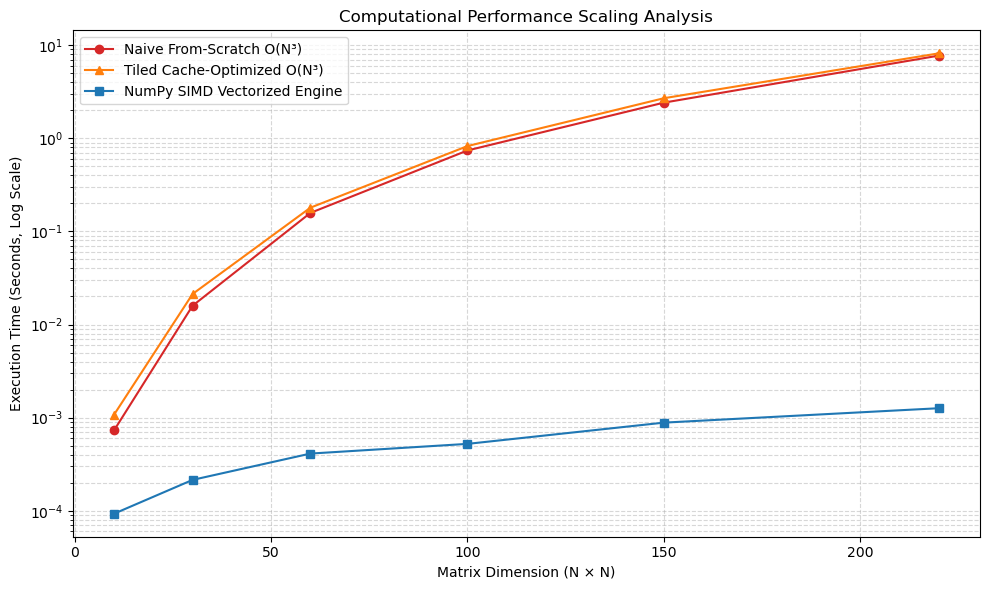

In [39]:
# Visualize performance curves
plt.figure(figsize=(10,6), dpi=100)
plt.plot(matrix_dimensions, naive_times, label='Naive From-Scratch O(N³)', color='#d62728', marker='o')
plt.plot(matrix_dimensions, tiled_times, label='Tiled Cache-Optimized O(N³)', color='#ff7f0e', marker='^')
plt.plot(matrix_dimensions, numpy_times, label='NumPy SIMD Vectorized Engine', color='#1f77b4', marker='s')
plt.yscale('log')
plt.xlabel('Matrix Dimension (N × N)')
plt.ylabel('Execution Time (Seconds, Log Scale)')
plt.title('Computational Performance Scaling Analysis')
plt.legend(frameon=True)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("output/benchmark_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

### Conclusion
Three implementations of matrix multiplication were comprehensively evaluated.
1. The Naive Algorithm: Provides a clear translation of linear algebra rules but scales poorly due to the unoptimized nature of multi-nested loops in Python.
2. The Tiled Implementation: Intended to improve low-level CPU cache reuse by dividing processing steps into sub-matrices.
3. NumPy Performance: Consistently achieves the lowest execution speeds by abstracting memory steps directly to backend optimized BLAS/LAPACK routines, applying hardware-level SIMD vectorization, and managing memory allocation outside Python's interpreter space.

### Technical Note: Python Tiling Paradox
As observed in the scaling metrics at dimensions $N \ge 150$, the Tiled algorithm executes slightly slower than the Naive loop structure. While tiling effectively minimizes hardware cache-miss latencies in compiled languages like C or C++, implementing it in pure Python expands our execution complexity from three nested loops into six nested loops.The significant structural overhead introduced by the Python interpreter processing these extra looping indices and tracking boundary metrics outweighs our hardware-level cache localization savings at this scale. Implementing the identical tiled framework in a compiled extension (such as Cython) would reveal its expected algorithmic dominance over naive loops as dimensions grow.